## Handling Mixed Variables

### Two Ways we get the data:-  
1. Something like in Cabin no. =  B5  
2. Something like in a single column = A, 1, 3, B, D  

In [69]:
import pandas as pd
import numpy as np

In [70]:
df = pd.read_csv('./Datasets/titanic.csv')

In [71]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [72]:
# extract numerical part
df['number_numerical'] = pd.to_numeric(df['number'],errors='coerce',downcast = 'integer')
df.sample(5)

,Cabin,Ticket,number,Survived,number_numerical
821,NaN,315098,2,1,2.0
872,B51 B53 B55,695,6,0,6.0
561,NaN,349251,4,0,4.0
14,NaN,350406,5,0,5.0
388,NaN,367655,6,0,6.0


In [73]:
df.isnull().sum()

Cabin               687
Ticket                0
number                0
Survived              0
number_numerical    139
dtype: int64

In [74]:
# extract categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)

In [75]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [76]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [77]:
df['cabin_num'] = df['Cabin'].str.extract(r'(\d+)')
df['cabin_cat'] = df['Cabin'].str[0]

df['cabin_cat'].sample(5)

509    NaN
162    NaN
206    NaN
699      F
389    NaN
Name: cabin_cat, dtype: object

<Axes: xlabel='cabin_cat'>

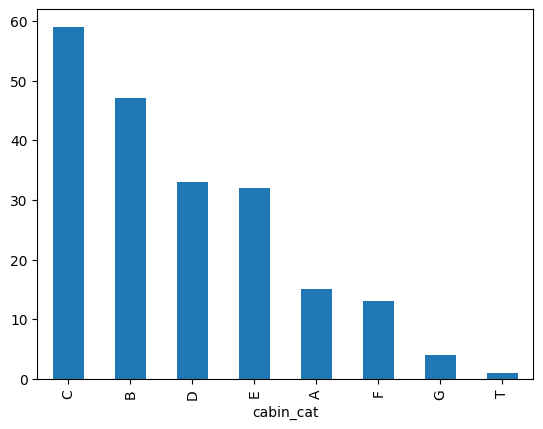

In [78]:
df['cabin_cat'].value_counts().plot(kind = 'bar')

In [84]:
df['ticket_num'] = df['Ticket'].str.split().str[-1]
df['ticket_num'] = pd.to_numeric(df['ticket_num'],errors='coerce',downcast='integer')
df['ticket_cat'] = df['Ticket'].str.split().str[0]
df['ticket_cat']= np.where(df['ticket_cat'].str.contains(r'\d', na=False), np.nan,df['ticket_cat'])

In [92]:
df.sample(5)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
197,NaN,4579,6,0,6.0,NaN,NaN,NaN,4579.0,NaN
745,B22,WE/P 5735,4,0,4.0,NaN,22,B,5735.0,WE/P
673,NaN,244270,3,1,3.0,NaN,NaN,NaN,244270.0,NaN
586,NaN,237565,2,0,2.0,NaN,NaN,NaN,237565.0,NaN
161,NaN,C.A. 33595,A,1,NaN,A,NaN,NaN,33595.0,C.A.
